Preparations

This section imports the libraries required for data processing,
time series analysis, statistical testing, and visualization.

Main packages used in this project include:
 `pandas` and `numpy` for data manipulation
 `matplotlib` for visualization
 `scipy.signal` for spectral analysis
 `statsmodels` for stationarity testing, autocorrelation analysis,
  and SARIMA modeling

To improve notebook readability, warning messages are suppressed
and plotting configurations are adjusted for higher-quality figures.

In [1]:
# Numerical computation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Signal processing
from scipy import signal

# Statistical analysis
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Environment settings
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

Data Collection and Preprocessing

The dataset contains daily bond spread observations together with
corresponding bond identifiers and yield information.


In [3]:
# Import raw dataset
df_raw = pd.read_excel(
    'database.xlsx',
    sheet_name='Sheet1',
    header=None,
    skiprows=2
)

# Assign column names
df_raw.columns = [
    'date',
    'bond_pair',
    'spread_bp',
    'otr_code',
    'offtr_code',
    'otr_yield',
    'offtr_yield'
]

# Remove missing spread observations
df = df_raw.dropna(subset=['spread_bp'])

# Convert date column to datetime format
df['date'] = pd.to_datetime(df['date'])

# Sort observations chronologically
df = df.sort_values('date')

# Reset row indices
df = df.reset_index(drop=True)

# Identify bond roll-over transition periods
df['is_transition'] = (
    df['bond_pair'] != df['bond_pair'].shift(1)
)

# Extract transition dates
transition_dates = df.loc[
    df['is_transition'],
    'date'
].tolist()

# Construct spread time series
spread = df.set_index('date')['spread_bp']

Check my data

Before conducting formal time series analysis,
summary statistics of the spread series are examined.

In [6]:
print("=" * 60)

print(f"Number of observations : {len(spread)}")

print(
    f"Sample period          : "
    f"{spread.index[0].date()} to {spread.index[-1].date()}"
)

print(
    f"Bond transition events : "
    f"{df['is_transition'].sum()}"
)

print(f"Mean spread            : {spread.mean():.3f} bp")

print(f"Spread volatility      : {spread.std():.3f} bp")

print(f"Minimum spread         : {spread.min():.3f} bp")

print(f"Maximum spread         : {spread.max():.3f} bp")

print("=" * 60)

Number of observations : 1120
Sample period          : 2020-11-25 to 2025-07-09
Bond transition events : 32
Mean spread            : 2.668 bp
Spread volatility      : 2.067 bp
Minimum spread         : -4.810 bp
Maximum spread         : 7.650 bp


The dataset contains 1120 valid spread observations
covering the period from November 2020 to July 2025.

The average spread is approximately 2.67 basis points,
with moderate variability relative to the mean level.

In total, 32 bond transition events are identified,
indicating multiple roll-over periods throughout the sample.

-----

Plot the orignal picture

This figure shows the full spread series over the sample period.
Vertical lines indicate bond transition dates, which may introduce
temporary structural changes due to roll-over effects.


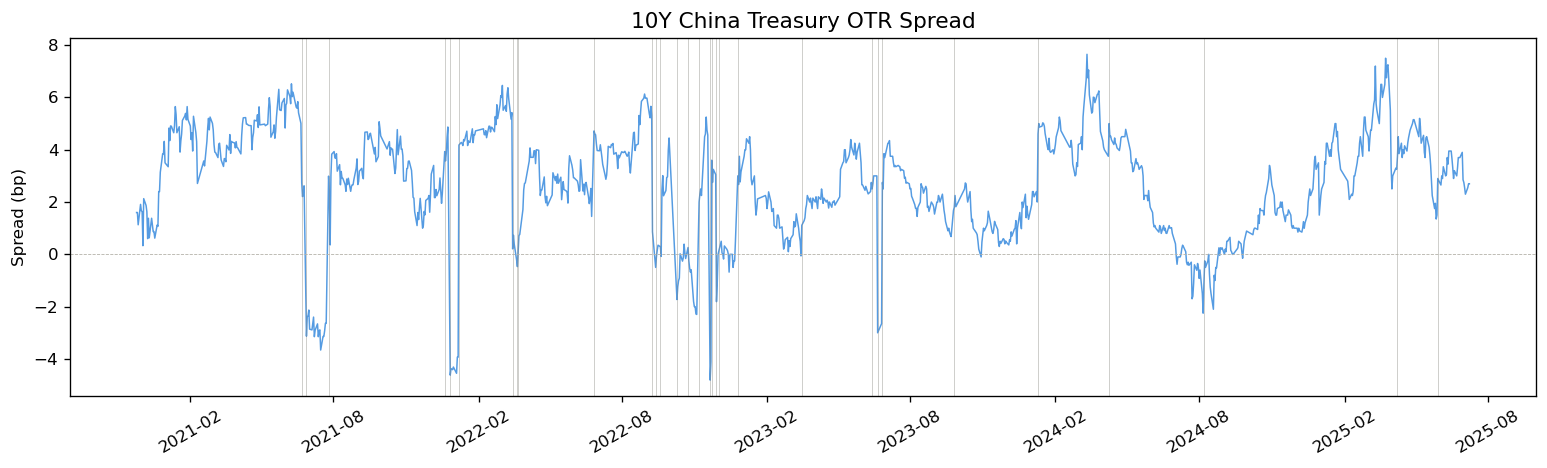

In [8]:
fig, ax = plt.subplots(figsize=(13, 4))

# Plot spread series
ax.plot(
    spread.index,
    spread.values,
    lw=0.9,
    color='#378ADD',
    alpha=0.85
)

# Mark transition dates
for d in transition_dates[1:]:
    ax.axvline(
        d,
        color='#888780',
        lw=0.6,
        alpha=0.4
    )

# Zero reference line
ax.axhline(
    0,
    color='#B4B2A9',
    lw=0.5,
    ls='--'
)

ax.set_title(
    '10Y China Treasury OTR Spread',
    fontsize=13
)

ax.set_ylabel('Spread (bp)')

# Format x-axis dates
ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=6)
)

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig('01_raw_spread.png', dpi=150)

plt.show()

ADF test for stationary

Before fitting a SARIMA model, we first examine whether
the spread series is stationary using the Augmented Dickey-Fuller (ADF) test.

The null hypothesis of the ADF test is that the series contains a unit root,
which implies non-stationarity.

A sufficiently small p-value allows rejection of the null hypothesis
and suggests that the series is stationary.

In [9]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, d=0):

    # Perform ADF test
    result = adfuller(series, autolag='AIC')

    test_stat = result[0]
    p_value = result[1]
    lags_used = result[2]

    print("=" * 50)

    print(f"Differencing order : d={d}")
    print(f"ADF statistic      : {test_stat:.4f}")
    print(f"P-value            : {p_value:.4f}")
    print(f"Lags used          : {lags_used}")

    if p_value < 0.05:

        print("Result             : stationary series")
        print("=" * 50)

        return d, series

    else:

        print("Result             : non-stationary series")
        print("Applying one additional differencing step...")
        print("=" * 50)

        series_diff = series.diff().dropna()

        return adf_test(series_diff, d=d+1)

final_d, stationary_series = adf_test(spread, d=0)

print(f"\nSuggested SARIMA differencing order: d={final_d}")

Differencing order : d=0
ADF statistic      : -4.8439
P-value            : 0.0000
Lags used          : 10
Result             : stationary series

Suggested SARIMA differencing order: d=0


The ADF statistic is significantly below the critical threshold,
and the p-value is effectively zero.

Therefore, the null hypothesis of a unit root is rejected,
indicating that the spread series is stationary without differencing.

This suggests that a SARIMA model with d=0 is appropriate.

---------

Rolling Spectral Analysis

To examine how the frequency structure of the spread evolves over time,
a rolling-window Fourier analysis is performed.

This helps identify whether cyclical behavior changes
across different market periods.

In [11]:
# Rolling-window FFT parameters
fs = 1
win = 100
hop = 10

values = spread.values
dates = spread.index

results = []

for start in range(0, len(values) - win, hop):

    # Extract rolling window segment
    segment = values[start : start + win]

    # Apply Hann window smoothing
    hann = np.hanning(win)
    segment = segment * hann

    # Compute FFT spectrum
    fft_vals = np.fft.rfft(segment)

    # Spectral power
    power = np.abs(fft_vals) ** 2

    # Frequency axis
    freqs = np.fft.rfftfreq(win, d=1/fs)

    # Convert frequencies into periods
    with np.errstate(divide='ignore'):
        periods = np.where(freqs > 0, 1 / freqs, np.nan)

    valid = freqs > 0

    results.append({
        'date'    : dates[start + win // 2],
        'periods' : periods[valid],
        'power'   : power[valid]
    })

print(f"Total rolling windows : {len(results)}")

print(
    f"Periods per window    : "
    f"{results[0]['periods'].shape[0]}"
)

print(
    f"Sample range          : "
    f"{results[0]['date'].date()} "
    f"to {results[-1]['date'].date()}"
)

Total rolling windows : 102
Periods per window    : 50
Sample range          : 2021-02-04 to 2025-04-11


The rolling spectral analysis generates 102 overlapping windows
across the sample period.

For each window, the dominant cyclical components of the spread
can be examined through spectral power distribution.


----------

Spectrogram Matrix Construction

The rolling FFT results are reorganized into matrix form
for spectrogram visualization.

In [23]:
# rows = period bins, columns = time windows
time_axis   = [r['date'] for r in results]
period_axis = results[0]['periods']
power_matrix = np.array([r['power'] for r in results]).T  

# convert to dB for better visual contrast
power_db = 10 * np.log10(power_matrix + 1e-12)
# the period with highest power in each column
dominant_idx    = np.argmax(power_matrix, axis=0)
dominant_period = period_axis[dominant_idx]

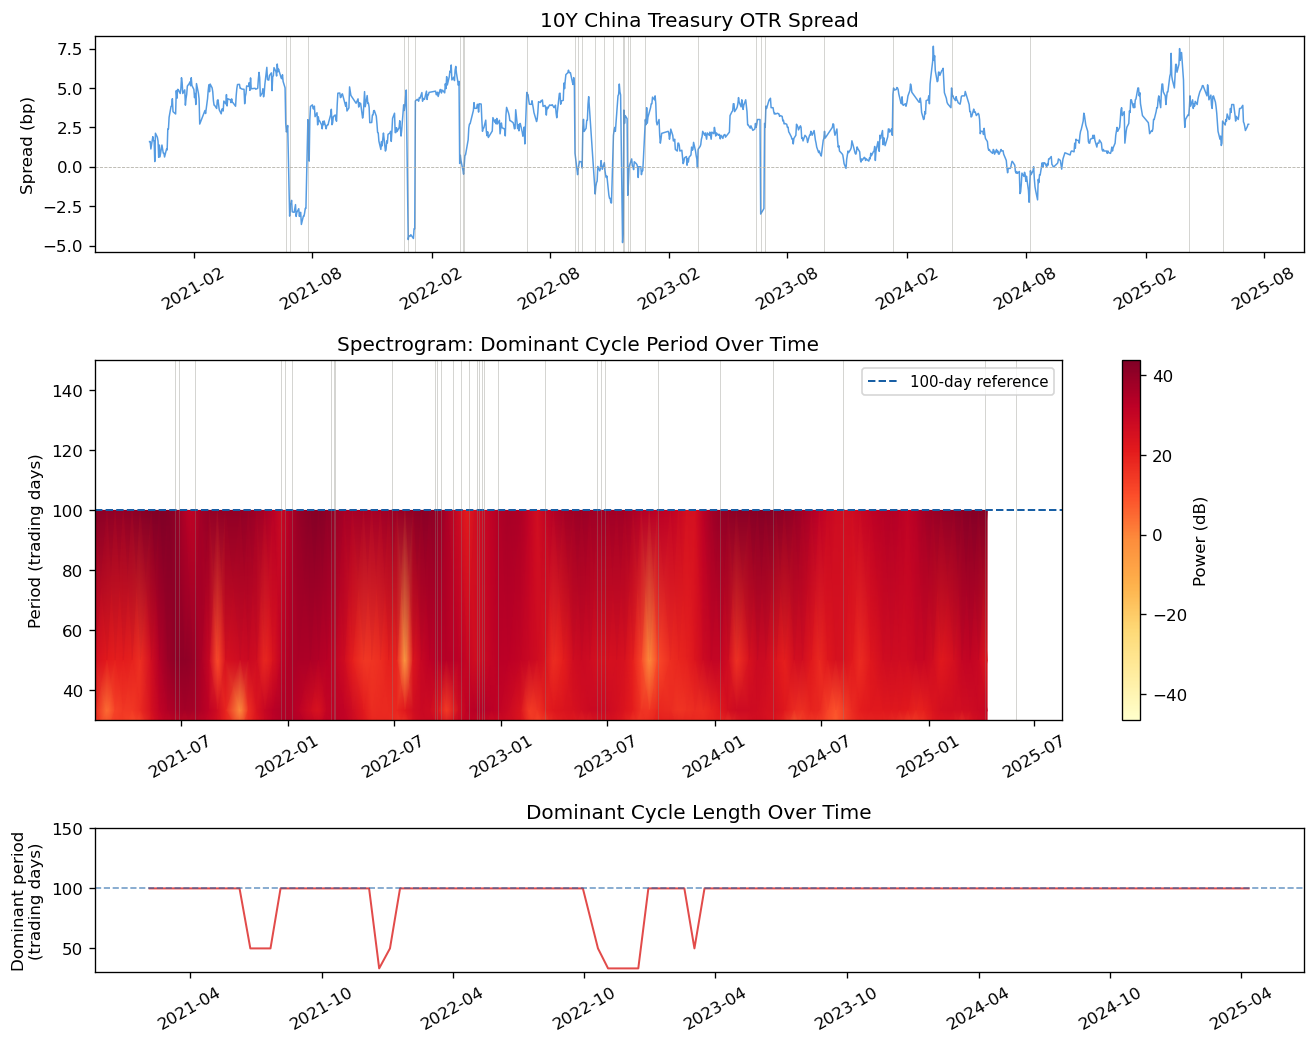

Dominant period summary:
  Mean : 93.8 trading days
  Min  : 33.3 trading days
  Max  : 100.0 trading days
  Std  : 18.1 trading days


In [24]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10),
                         gridspec_kw={'height_ratios': [1.5, 2.5, 1]})

# Top panel: raw spread series 
axes[0].plot(spread.index, spread.values, lw=0.9, color='#378ADD', alpha=0.85)
for d in transition_dates[1:]:
    axes[0].axvline(d, color='#888780', lw=0.6, alpha=0.35)
axes[0].axhline(0, color='#B4B2A9', lw=0.5, ls='--')
axes[0].set_ylabel('Spread (bp)')
axes[0].set_title('10Y China Treasury OTR Spread', fontsize=12)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(axes[0].get_xticklabels(), rotation=30)

# Middle panel: spectrogram heatmap 
im = axes[1].pcolormesh(
    time_axis,
    period_axis,
    power_db,
    shading='gouraud',  # smooth interpolation
    cmap='YlOrRd'       # yellow → orange → red: weak → strong
)

# reference line at 100 trading days
axes[1].axhline(y=100, color='#185FA5', lw=1.2, ls='--', label='100-day reference')

# bond transition lines
for d in transition_dates[1:]:
    axes[1].axvline(d, color='#888780', lw=0.6, alpha=0.35)

# focus on 30-150 day band
axes[1].set_ylim(30, 150)
axes[1].set_ylabel('Period (trading days)')
axes[1].set_title('Spectrogram: Dominant Cycle Period Over Time', fontsize=12)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(axes[1].get_xticklabels(), rotation=30)
axes[1].legend(loc='upper right', fontsize=9)
plt.colorbar(im, ax=axes[1], label='Power (dB)')

#  Bottom panel: dominant period over time 
axes[2].plot(time_axis, dominant_period, color='#E24B4A', lw=1.2)
axes[2].axhline(y=100, color='#185FA5', lw=1, ls='--', alpha=0.6)
axes[2].set_ylim(30, 150)
axes[2].set_ylabel('Dominant period\n(trading days)')
axes[2].set_title('Dominant Cycle Length Over Time', fontsize=12)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(axes[2].get_xticklabels(), rotation=30)

plt.subplots_adjust(hspace=0.45, bottom=0.1)
plt.savefig('03_spectrogram.png', dpi=150)
plt.show()

# Print dominant period summary
print("Dominant period summary:")
print(f"  Mean : {dominant_period.mean():.1f} trading days")
print(f"  Min  : {dominant_period.min():.1f} trading days")
print(f"  Max  : {dominant_period.max():.1f} trading days")
print(f"  Std  : {dominant_period.std():.1f} trading days")

In many rolling windows, the dominant cycle length stays close
to the 100-day upper boundary, suggesting that low-frequency
movements account for a large portion of the spread variation.

However, several shorter-cycle episodes are also observed,
particularly around late 2021 and late 2022,
where the dominant period temporarily declines toward
approximately 30–60 trading days.

Overall, the frequency structure of the spread appears
relatively stable over time, the presence of persistent low-frequency behavior
further supports the use of low-order time series models
in the subsequent SARIMA analysis.


----------

Fitting the SARIMA model

ACF and PACF plots to determine p, q, P, Q

ACF and PACF plots are used to help identify
appropriate autoregressive and moving-average orders
for the SARIMA model.

Both short-range and long-range lag structures are examined
to capture potential seasonal dynamics in the spread series.

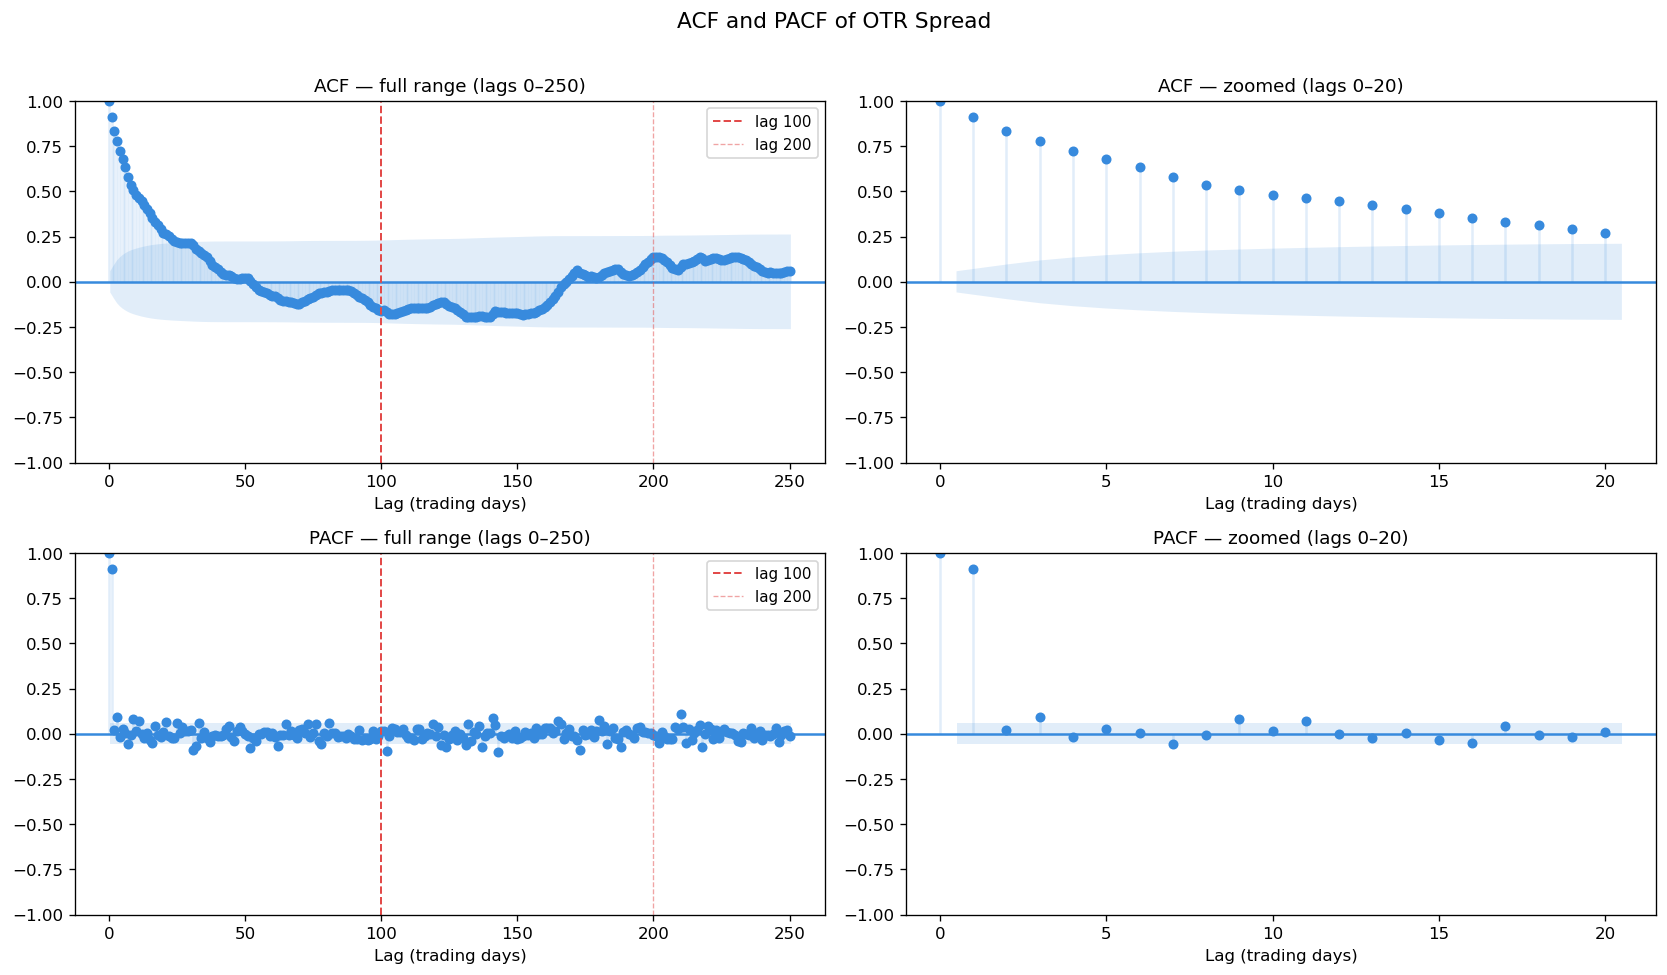

In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

acf_kwargs  = dict(alpha=0.05, color='#378ADD', vlines_kwargs={'colors': '#378ADD'})
pacf_kwargs = dict(alpha=0.05, color='#378ADD', vlines_kwargs={'colors': '#378ADD'},
                   method='ywm')

# ACF full range 
plot_acf(spread, lags=250, ax=axes[0, 0], **acf_kwargs)
axes[0, 0].set_title('ACF — full range (lags 0–250)', fontsize=11)
axes[0, 0].set_xlabel('Lag (trading days)')
axes[0, 0].axvline(x=100, color='#E24B4A', lw=1.2, ls='--', label='lag 100')
axes[0, 0].axvline(x=200, color='#E24B4A', lw=0.8, ls='--', alpha=0.5, label='lag 200')
axes[0, 0].legend(fontsize=9)

#  ACF zoomed 
plot_acf(spread, lags=20, ax=axes[0, 1], **acf_kwargs)
axes[0, 1].set_title('ACF — zoomed (lags 0–20)', fontsize=11)
axes[0, 1].set_xlabel('Lag (trading days)')

# PACF full range -
plot_pacf(spread, lags=250, ax=axes[1, 0], **pacf_kwargs)
axes[1, 0].set_title('PACF — full range (lags 0–250)', fontsize=11)
axes[1, 0].set_xlabel('Lag (trading days)')
axes[1, 0].axvline(x=100, color='#E24B4A', lw=1.2, ls='--', label='lag 100')
axes[1, 0].axvline(x=200, color='#E24B4A', lw=0.8, ls='--', alpha=0.5, label='lag 200')
axes[1, 0].legend(fontsize=9)

#  PACF zoomed 
plot_pacf(spread, lags=20, ax=axes[1, 1], **pacf_kwargs)
axes[1, 1].set_title('PACF — zoomed (lags 0–20)', fontsize=11)
axes[1, 1].set_xlabel('Lag (trading days)')

# shade the confidence bands blue
for ax in axes.flat:
    for collection in ax.collections:
        collection.set_facecolor('#378ADD')
        collection.set_alpha(0.15)

plt.suptitle('ACF and PACF of OTR Spread', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('04_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

Based on these observations, a relatively small parameter grid
is considered for SARIMA estimation.

Model selection is then performed using the Akaike Information Criterion (AIC),
which balances model fit and complexity.


-----------------

Using AIC to find proper coefficient parameters

Instead of using a purely standard ARIMA specification,
the Fourier terms are constructed using sine and cosine functions
with different harmonic orders, allowing the model
to approximate persistent periodic movements
without introducing a large number of seasonal parameters.

A small parameter grid is then evaluated using AIC and BIC criteria
to balance goodness-of-fit and model complexity.

In [26]:
# q = 1 or 2 (MA order)
# K = 1 or 3 (seasonal complexity, equivalent to P=0 vs P=1)


import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

n = len(spread)
t = np.arange(n)
s = 100

results = []

for q in [1, 2]:
    for K in [1, 3]:
        
        # build Fourier terms for this K
        fourier = pd.DataFrame(index=spread.index)
        for k in range(1, K + 1):
            fourier[f'sin_{k}'] = np.sin(2 * np.pi * k * t / s)
            fourier[f'cos_{k}'] = np.cos(2 * np.pi * k * t / s)

        label = f'ARIMA(1,0,{q}) + Fourier(K={K})'
        print(f"Fitting {label} ...", end=' ', flush=True)
        
        try:
            model = ARIMA(
                spread,
                order=(1, 0, q),
                exog=fourier,
                enforce_stationarity=True,
                enforce_invertibility=True
            )
            fitted = model.fit(method='innovations_mle')
            results.append({
                'model'  : label,
                'q'      : q,
                'K'      : K,
                'AIC'    : round(fitted.aic, 2),
                'BIC'    : round(fitted.bic, 2),
                'AR1'    : round(fitted.arparams[0], 4),
                'fitted' : fitted
            })
            print(f"AIC={fitted.aic:.2f}  BIC={fitted.bic:.2f}")
        except Exception as e:
            print(f"FAILED: {e}")

# --- rank by AIC ---
results.sort(key=lambda x: x['AIC'])

print("\n" + "=" * 60)
print("Results ranked by AIC:")
print("=" * 60)
for r in results:
    marker = " ← best" if r == results[0] else ""
    print(f"  {r['model']}  AIC={r['AIC']}  BIC={r['BIC']}{marker}")

print("=" * 60)
best = results[0]
best_model_fitted = best['fitted']
print(f"\nBest model : {best['model']}")
print(f"AR(1) coef : {best['AR1']}")
print(f"AIC        : {best['AIC']}")
print(f"BIC        : {best['BIC']}")

Fitting ARIMA(1,0,1) + Fourier(K=1) ... AIC=2813.21  BIC=2843.34
Fitting ARIMA(1,0,1) + Fourier(K=3) ... AIC=2819.15  BIC=2869.36
Fitting ARIMA(1,0,2) + Fourier(K=1) ... AIC=2805.03  BIC=2840.18
Fitting ARIMA(1,0,2) + Fourier(K=3) ... AIC=2810.57  BIC=2865.81

Results ranked by AIC:
  ARIMA(1,0,2) + Fourier(K=1)  AIC=2805.03  BIC=2840.18 ← best
  ARIMA(1,0,2) + Fourier(K=3)  AIC=2810.57  BIC=2865.81
  ARIMA(1,0,1) + Fourier(K=1)  AIC=2813.21  BIC=2843.34
  ARIMA(1,0,1) + Fourier(K=3)  AIC=2819.15  BIC=2869.36

Best model : ARIMA(1,0,2) + Fourier(K=1)
AR(1) coef : 0.9309
AIC        : 2805.03
BIC        : 2840.18


Among the candidate specifications,
ARIMA(1,0,2) with a single Fourier component (K=1)
achieves the lowest AIC value.


--------------

Analyizing the half-life of mean reversion

To quantify the speed of mean reversion,
the half-life implied by the fitted ARIMA model is estimated.

The half-life measures how long it takes for a temporary deviation
from the long-run mean to decay by 50%.

A shorter half-life indicates faster mean reversion,
while a longer half-life suggests more persistent spread dynamics.

The estimate is based on the AR(1) coefficient
from the selected ARIMA specification.

Model coefficients:
  AR(1) : 0.9309  (p=0.0000)
  MA(1) : -0.0369  (p=0.4459)
  MA(2) : -0.1053  (p=0.0000)

Half-life calculation:
  AR(1) coefficient : 0.9309
  Half-life         : 9.7 trading days
  Interpretation: after a shock, the OTR spread
  takes 10 trading days to revert halfway
  back to its long-run mean of 2.67 bp


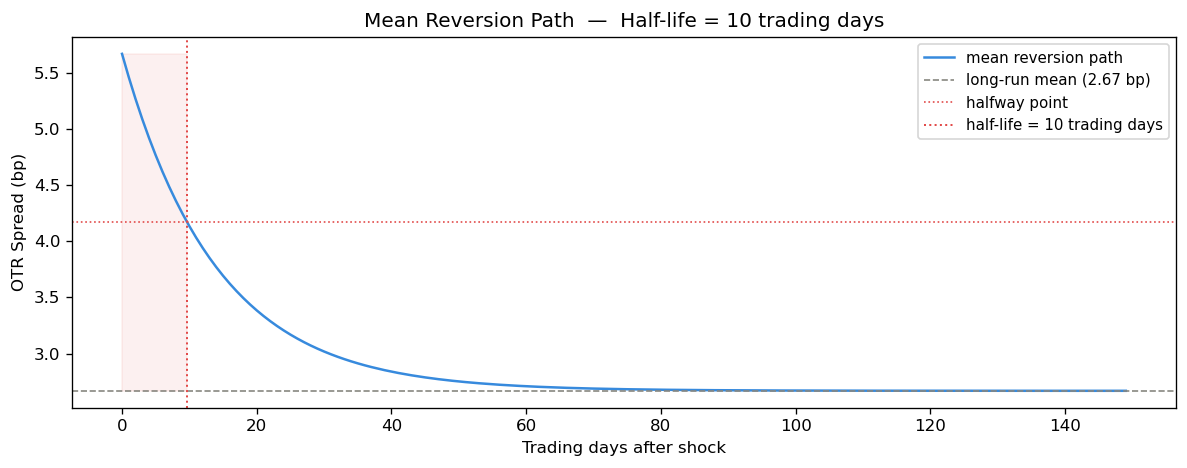

In [27]:
# extract coefficients from best model 
ar1 = best_model_fitted.arparams[0]
ma1 = best_model_fitted.maparams[0]
ma2 = best_model_fitted.maparams[1]

print("=" * 50)
print("Model coefficients:")
print(f"  AR(1) : {ar1:.4f}  (p={best_model_fitted.pvalues['ar.L1']:.4f})")
print(f"  MA(1) : {ma1:.4f}  (p={best_model_fitted.pvalues['ma.L1']:.4f})")
print(f"  MA(2) : {ma2:.4f}  (p={best_model_fitted.pvalues['ma.L2']:.4f})")
print("=" * 50)

# calculate half-life 
# number of trading days for a deviation to decay to half its size
half_life = -np.log(2) / np.log(ar1)

print("\nHalf-life calculation:")
print(f"  AR(1) coefficient : {ar1:.4f}")
print(f"  Half-life         : {half_life:.1f} trading days")
print("=" * 50)
print(f"  Interpretation: after a shock, the OTR spread")
print(f"  takes {half_life:.0f} trading days to revert halfway")
print(f"  back to its long-run mean of {spread.mean():.2f} bp")
print("=" * 50)

# plot mean reversion path 
days = np.arange(0, 150)
initial_deviation = 3.0
mean_level = spread.mean()
reversion_path = mean_level + initial_deviation * (ar1 ** days)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(days, reversion_path, color='#378ADD', lw=1.5,
        label='mean reversion path')
ax.axhline(y=mean_level, color='#888780', lw=1, ls='--',
           label=f'long-run mean ({mean_level:.2f} bp)')
ax.axhline(y=mean_level + initial_deviation/2,
           color='#E24B4A', lw=1, ls=':',
           label='halfway point')
ax.axvline(x=half_life, color='#E24B4A', lw=1.2, ls=':',
           label=f'half-life = {half_life:.0f} trading days')

ax.fill_betweenx(
    [mean_level, mean_level + initial_deviation],
    0, half_life,
    alpha=0.08, color='#E24B4A'
)

ax.set_xlabel('Trading days after shock')
ax.set_ylabel('OTR Spread (bp)')
ax.set_title(f'Mean Reversion Path  —  Half-life = {half_life:.0f} trading days',
             fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('05_half_life.png', dpi=150)
plt.show()


Residual diagnostics

After selecting the SARIMA specification,
residual diagnostics are performed to evaluate model adequacy.

If the model captures the main dependence structure of the spread series,
the residuals should behave approximately like white noise.

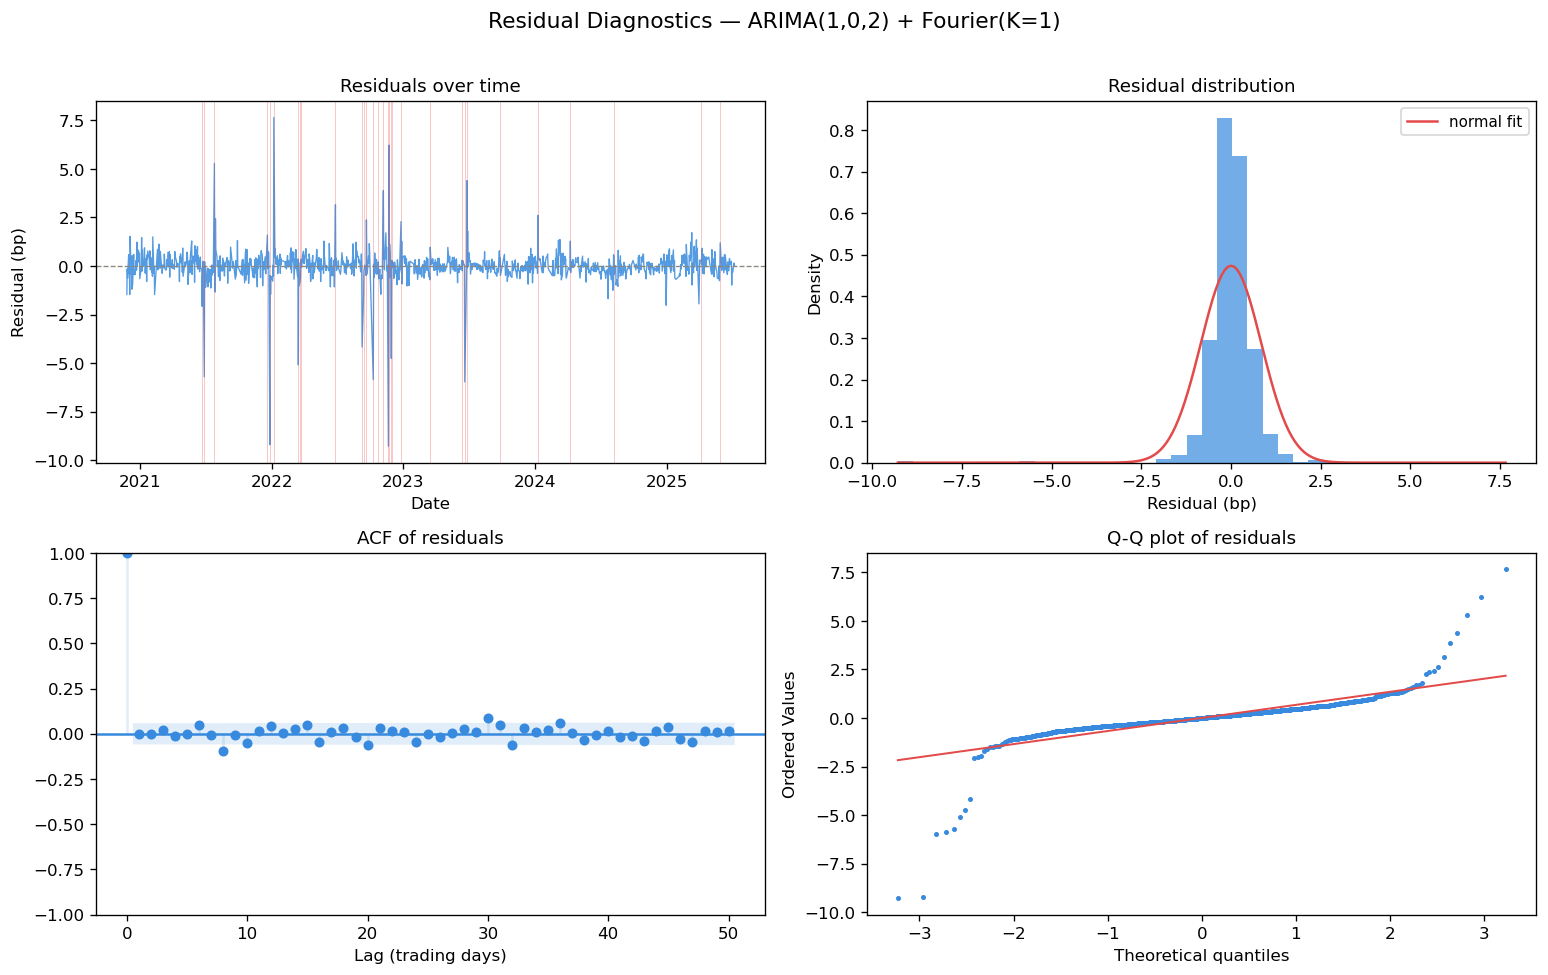

Ljung-Box Test (H0: residuals are white noise)
  Lag 10 : stat=16.15  p=0.0954  ✓ white noise
  Lag 20 : stat=29.75  p=0.0740  ✓ white noise
  Lag 30 : stat=43.83  p=0.0494  ✗ autocorrelation remains


In [28]:
import scipy.stats as stats

residuals = best_model_fitted.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

#  top-left: residuals over time 
axes[0, 0].plot(spread.index, residuals, color='#378ADD', lw=0.8, alpha=0.85)
axes[0, 0].axhline(0, color='#888780', lw=0.8, ls='--')
for d in transition_dates[1:]:
    axes[0, 0].axvline(d, color='#E24B4A', lw=0.6, alpha=0.3)
axes[0, 0].set_title('Residuals over time', fontsize=11)
axes[0, 0].set_ylabel('Residual (bp)')
axes[0, 0].set_xlabel('Date')

# top-right: histogram of residuals 
axes[0, 1].hist(residuals, bins=40, color='#378ADD', alpha=0.7, density=True)
x = np.linspace(residuals.min(), residuals.max(), 200)
axes[0, 1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()),
                color='#E24B4A', lw=1.5, label='normal fit')
axes[0, 1].set_title('Residual distribution', fontsize=11)
axes[0, 1].set_xlabel('Residual (bp)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend(fontsize=9)

# bottom-left: ACF of residuals 
plot_acf(residuals, lags=50, alpha=0.05, ax=axes[1, 0],
         color='#378ADD', vlines_kwargs={'colors': '#378ADD'})
axes[1, 0].set_title('ACF of residuals', fontsize=11)
axes[1, 0].set_xlabel('Lag (trading days)')

# shade confidence band blue
for collection in axes[1, 0].collections:
    collection.set_facecolor('#378ADD')
    collection.set_alpha(0.15)

# bottom-right: Q-Q plot 
stats.probplot(residuals, dist='norm', plot=axes[1, 1])
axes[1, 1].get_lines()[0].set(color='#378ADD', markersize=2)
axes[1, 1].get_lines()[1].set(color='#E24B4A', lw=1.2)
axes[1, 1].set_title('Q-Q plot of residuals', fontsize=11)

plt.suptitle('Residual Diagnostics — ARIMA(1,0,2) + Fourier(K=1)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('06_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Ljung-Box test 
# H0: residuals are white noise 
# p-value > 0.05 → fail to reject H0 → residuals are clean
lb = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)

print("=" * 50)
print("Ljung-Box Test (H0: residuals are white noise)")
print("=" * 50)
for lag, row in lb.iterrows():
    result = "✓ white noise" if row['lb_pvalue'] > 0.05 else "✗ autocorrelation remains"
    print(f"  Lag {lag:2d} : stat={row['lb_stat']:.2f}  p={row['lb_pvalue']:.4f}  {result}")
print("=" * 50)

The diagnostics indicate that the selected
SARIMA specification provides a reasonably adequate fit,
although the residuals are not perfectly Gaussian
and some weak long-range dependence may persist.

----------

To evaluate the predictive performance of the selected model,
an out-of-sample forecasting exercise is conducted.

The dataset is divided into:

80% training observations
20% testing observations

The ARIMA-Fourier model is fitted only on the training set,
while forecasts are generated for the unseen test period.

This allows assessment of how well the model generalizes
beyond the estimation sample.

Train : 2020-11-25 → 2024-08-02  (896 days)
Test  : 2024-08-05  → 2025-07-09   (224 days)

Fitting model on train set ... Done.

Forecast accuracy:
  ARIMA MAE  : 1.4884 bp
  RW MAE     : 3.3064 bp
  ARIMA RMSE : 1.8964 bp
  RW RMSE    : 3.7763 bp

  MAE  improvement over RW : 55.0%
  RMSE improvement over RW : 49.8%


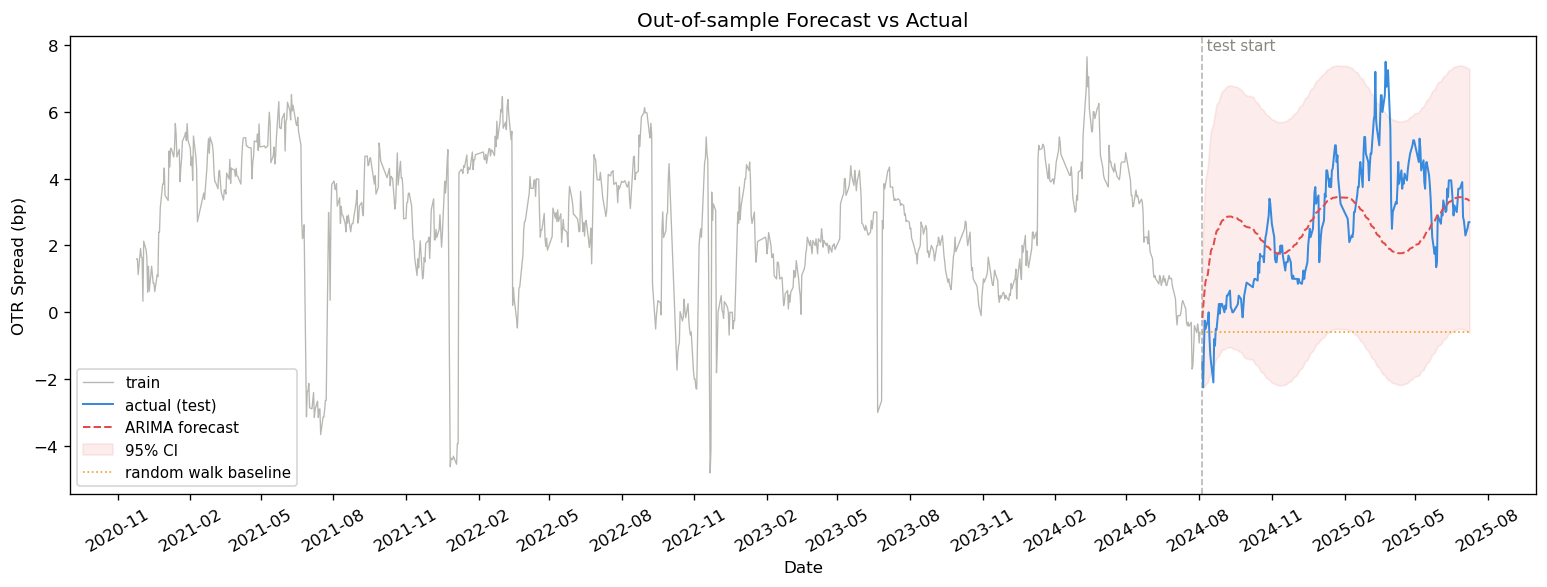

In [29]:
import matplotlib.dates as mdates
#t80% train, 20% test 
split_idx   = int(len(spread) * 0.8)
train        = spread.iloc[:split_idx]
test         = spread.iloc[split_idx:]

print(f"Train : {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} days)")
print(f"Test  : {test.index[0].date()}  → {test.index[-1].date()}   ({len(test)} days)")

#rebuild Fourier terms for full dataset 
n = len(spread)
t_forecast = np.arange(n)
s = 100
K = 1

fourier_full = pd.DataFrame(index=spread.index)
for k in range(1, K + 1):
    fourier_full[f'sin_{k}'] = np.sin(2 * np.pi * k * t / s)
    fourier_full[f'cos_{k}'] = np.cos(2 * np.pi * k * t / s)

fourier_train = fourier_full.iloc[:split_idx]
fourier_test  = fourier_full.iloc[split_idx:]

#fit model on train set only 
print("\nFitting model on train set ...", end=' ', flush=True)
model_train = ARIMA(
    train,
    order=(1, 0, 2),
    exog=fourier_train,
    enforce_stationarity=True,
    enforce_invertibility=True
)
fitted_train = model_train.fit()
print("Done.")

# forecast over test period 
forecast = fitted_train.forecast(
    steps=len(test),
    exog=fourier_test
)
forecast_ci = fitted_train.get_forecast(
    steps=len(test),
    exog=fourier_test
).conf_int(alpha=0.05)   # 95% confidence interval

# random walk baseline Tommorrow=Today
rw_forecast = train.iloc[-1] * np.ones(len(test))

# --- compute forecast errors ---
mae_arima = np.mean(np.abs(forecast.values - test.values))
mae_rw    = np.mean(np.abs(rw_forecast - test.values))
rmse_arima = np.sqrt(np.mean((forecast.values - test.values) ** 2))
rmse_rw    = np.sqrt(np.mean((rw_forecast - test.values) ** 2))

print("\n" + "=" * 50)
print("Forecast accuracy:")
print("=" * 50)
print(f"  ARIMA MAE  : {mae_arima:.4f} bp")
print(f"  RW MAE     : {mae_rw:.4f} bp")
print(f"  ARIMA RMSE : {rmse_arima:.4f} bp")
print(f"  RW RMSE    : {rmse_rw:.4f} bp")
print(f"\n  MAE  improvement over RW : {(1 - mae_arima/mae_rw)*100:.1f}%")
print(f"  RMSE improvement over RW : {(1 - rmse_arima/rmse_rw)*100:.1f}%")
print("=" * 50)

#  plot 
fig, ax = plt.subplots(figsize=(13, 5))

# training data
ax.plot(train.index, train.values,
        color='#888780', lw=0.8, alpha=0.6, label='train')

# actual test values
ax.plot(test.index, test.values,
        color='#378ADD', lw=1.2, label='actual (test)')

# ARIMA forecast
ax.plot(test.index, forecast.values,
        color='#E24B4A', lw=1.2, ls='--', label='ARIMA forecast')

# 95% confidence interval
ax.fill_between(
    test.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='#E24B4A', alpha=0.1, label='95% CI'
)

# random walk baseline
ax.plot(test.index, rw_forecast,
        color='#EF9F27', lw=1, ls=':', label='random walk baseline')

# train/test split line
ax.axvline(test.index[0], color='#888780', lw=1, ls='--', alpha=0.6)
ax.text(test.index[0], ax.get_ylim()[1] * 0.95,
        ' test start', fontsize=9, color='#888780')

ax.set_title('Out-of-sample Forecast vs Actual', fontsize=12)
ax.set_ylabel('OTR Spread (bp)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('07_forecast.png', dpi=150)
plt.show()


The model demonstrates moderate but economically meaningful
forecasting ability while remaining relatively parsimonious
and interpretable.